In [1]:
import src
print(src.__file__)                 # __init__.py 실제 위치 확인
from pathlib import Path
fpath = Path(src.__file__).resolve().parent / "fonts"
print(fpath, fpath.exists())
print(list(fpath.glob("*.ttf")))    # ttf 파일 목록 나와야 정상

c:\Users\asskj\data-analysis-portfolio\olist\src\__init__.py
C:\Users\asskj\data-analysis-portfolio\olist\src\fonts True
[WindowsPath('C:/Users/asskj/data-analysis-portfolio/olist/src/fonts/NotoSansKR-Black.ttf'), WindowsPath('C:/Users/asskj/data-analysis-portfolio/olist/src/fonts/NotoSansKR-Bold.ttf'), WindowsPath('C:/Users/asskj/data-analysis-portfolio/olist/src/fonts/NotoSansKR-ExtraBold.ttf'), WindowsPath('C:/Users/asskj/data-analysis-portfolio/olist/src/fonts/NotoSansKR-ExtraLight.ttf'), WindowsPath('C:/Users/asskj/data-analysis-portfolio/olist/src/fonts/NotoSansKR-Light.ttf'), WindowsPath('C:/Users/asskj/data-analysis-portfolio/olist/src/fonts/NotoSansKR-Medium.ttf'), WindowsPath('C:/Users/asskj/data-analysis-portfolio/olist/src/fonts/NotoSansKR-Regular.ttf'), WindowsPath('C:/Users/asskj/data-analysis-portfolio/olist/src/fonts/NotoSansKR-SemiBold.ttf')]


In [2]:
import matplotlib.pyplot as plt
print(plt.rcParams['font.family'])   # Noto Sans KR 계열 이름이 떠야 정상

['Noto Sans KR']


In [3]:
import pandas as pd
from src import my_qtcheck, my_stats, my_plot

master = pd.read_parquet("data/processed/master.parquet")
item_base = pd.read_parquet("data/processed/item_base.parquet")
assert master["order_id"].is_unique and len(master) == 96204

In [4]:
orders = pd.read_csv("data/raw/olist_orders_dataset.csv", parse_dates=["order_purchase_timestamp"])

In [5]:
monthly = (master.assign(month=master.purchase_ts.dt.to_period("M"))
                  .groupby("month")
                  .agg(n=("order_id","count"),
                       late_rate=("late","mean"),
                       n_reviewed=("low","count"),
                       low_rate=("low","mean")))

In [6]:
master.late.value_counts(normalize=True)
master.low.value_counts(dropna=False, normalize=True)
pd.crosstab(master.late, master.low, dropna=False)   # 3단계 대상 8,247건 재확인

low,0.0,1.0,NaN
late,,,
0,80935,8247,490
1,2398,3981,153


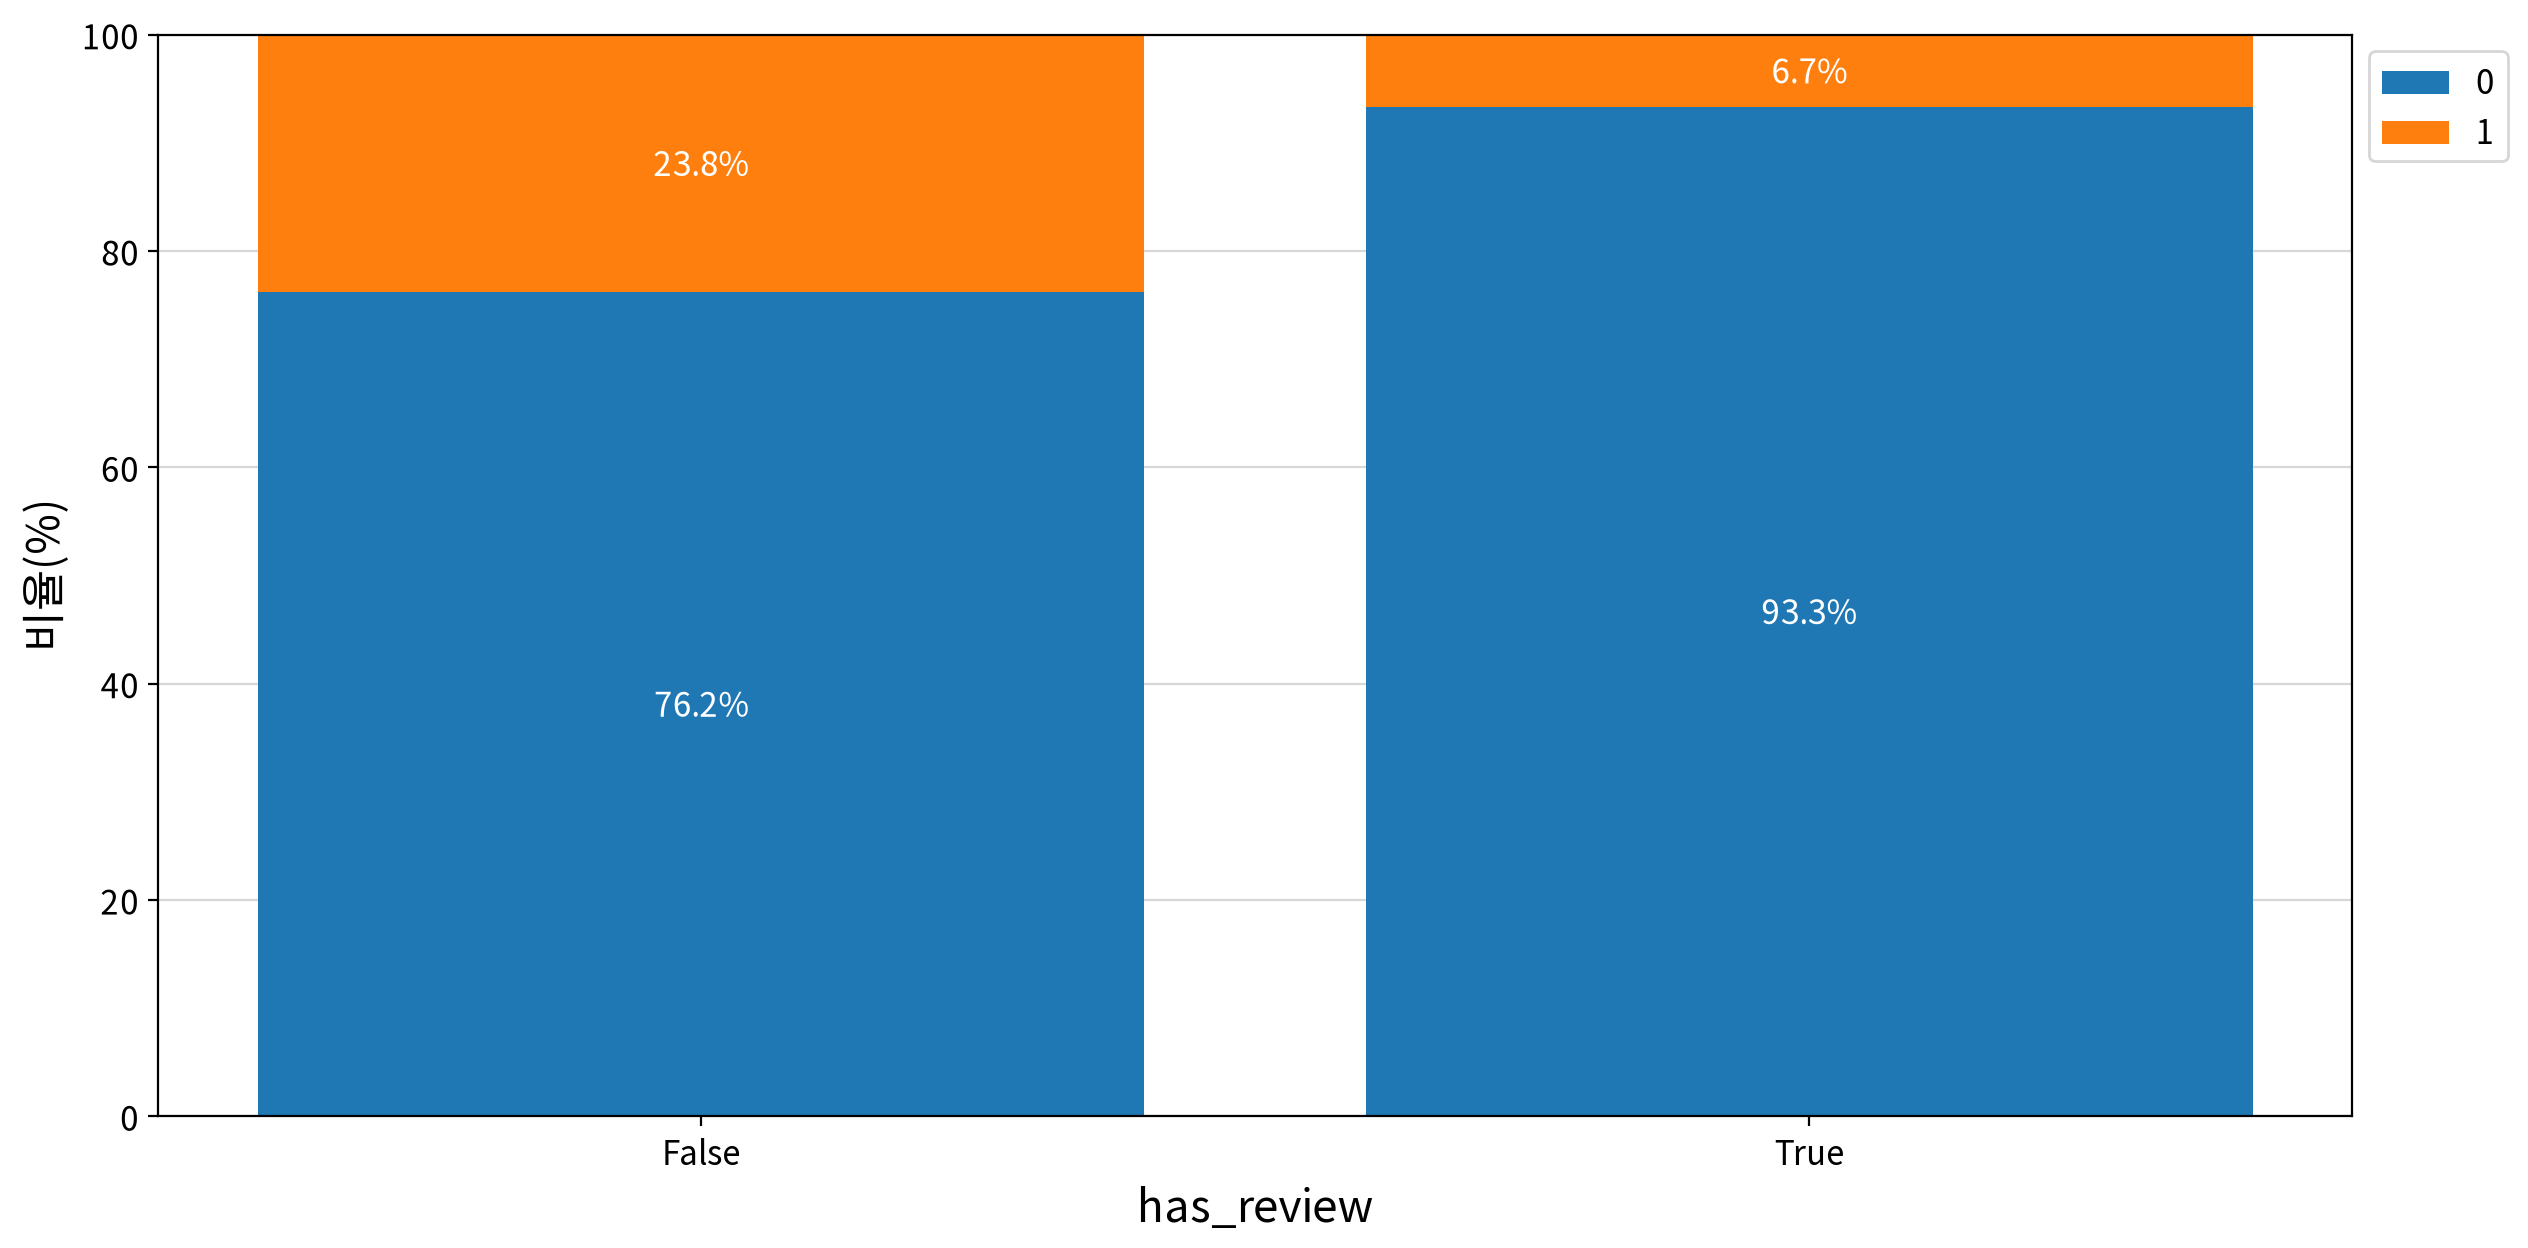

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
has_review,late,Chi-square test of independence,293.0742,1,0.0,True,0.0552,Negligible,43.66,True


In [7]:
tmp = master.assign(has_review=master.low.notna())
my_stats.chi2_independence(tmp, x="has_review", y="late")

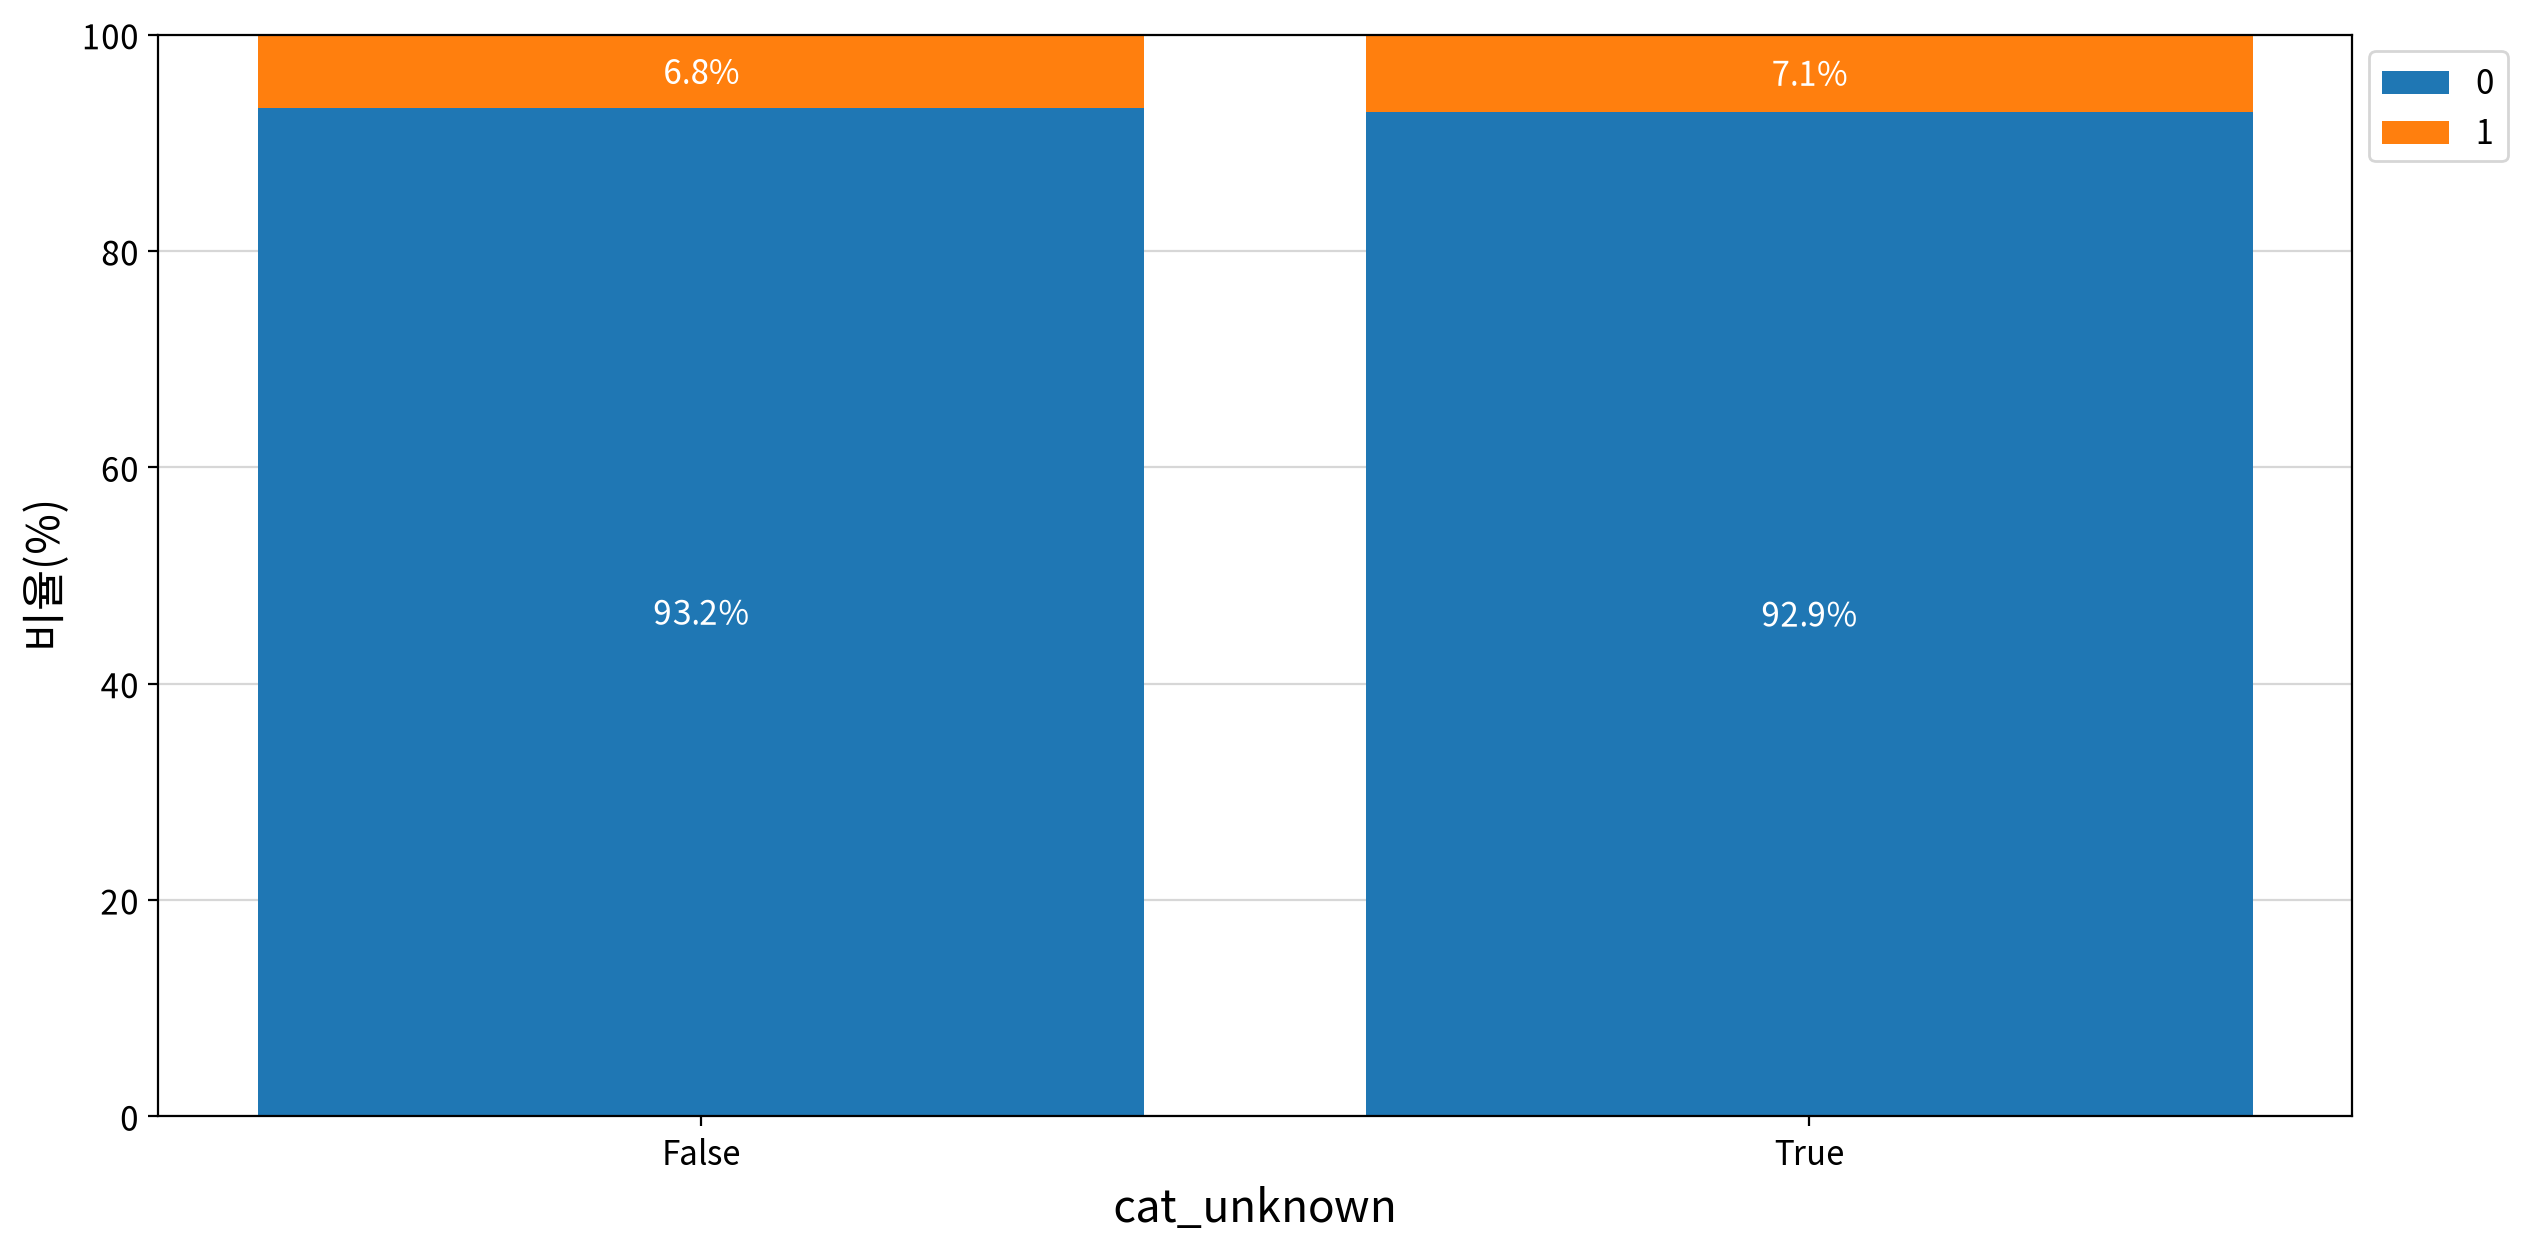

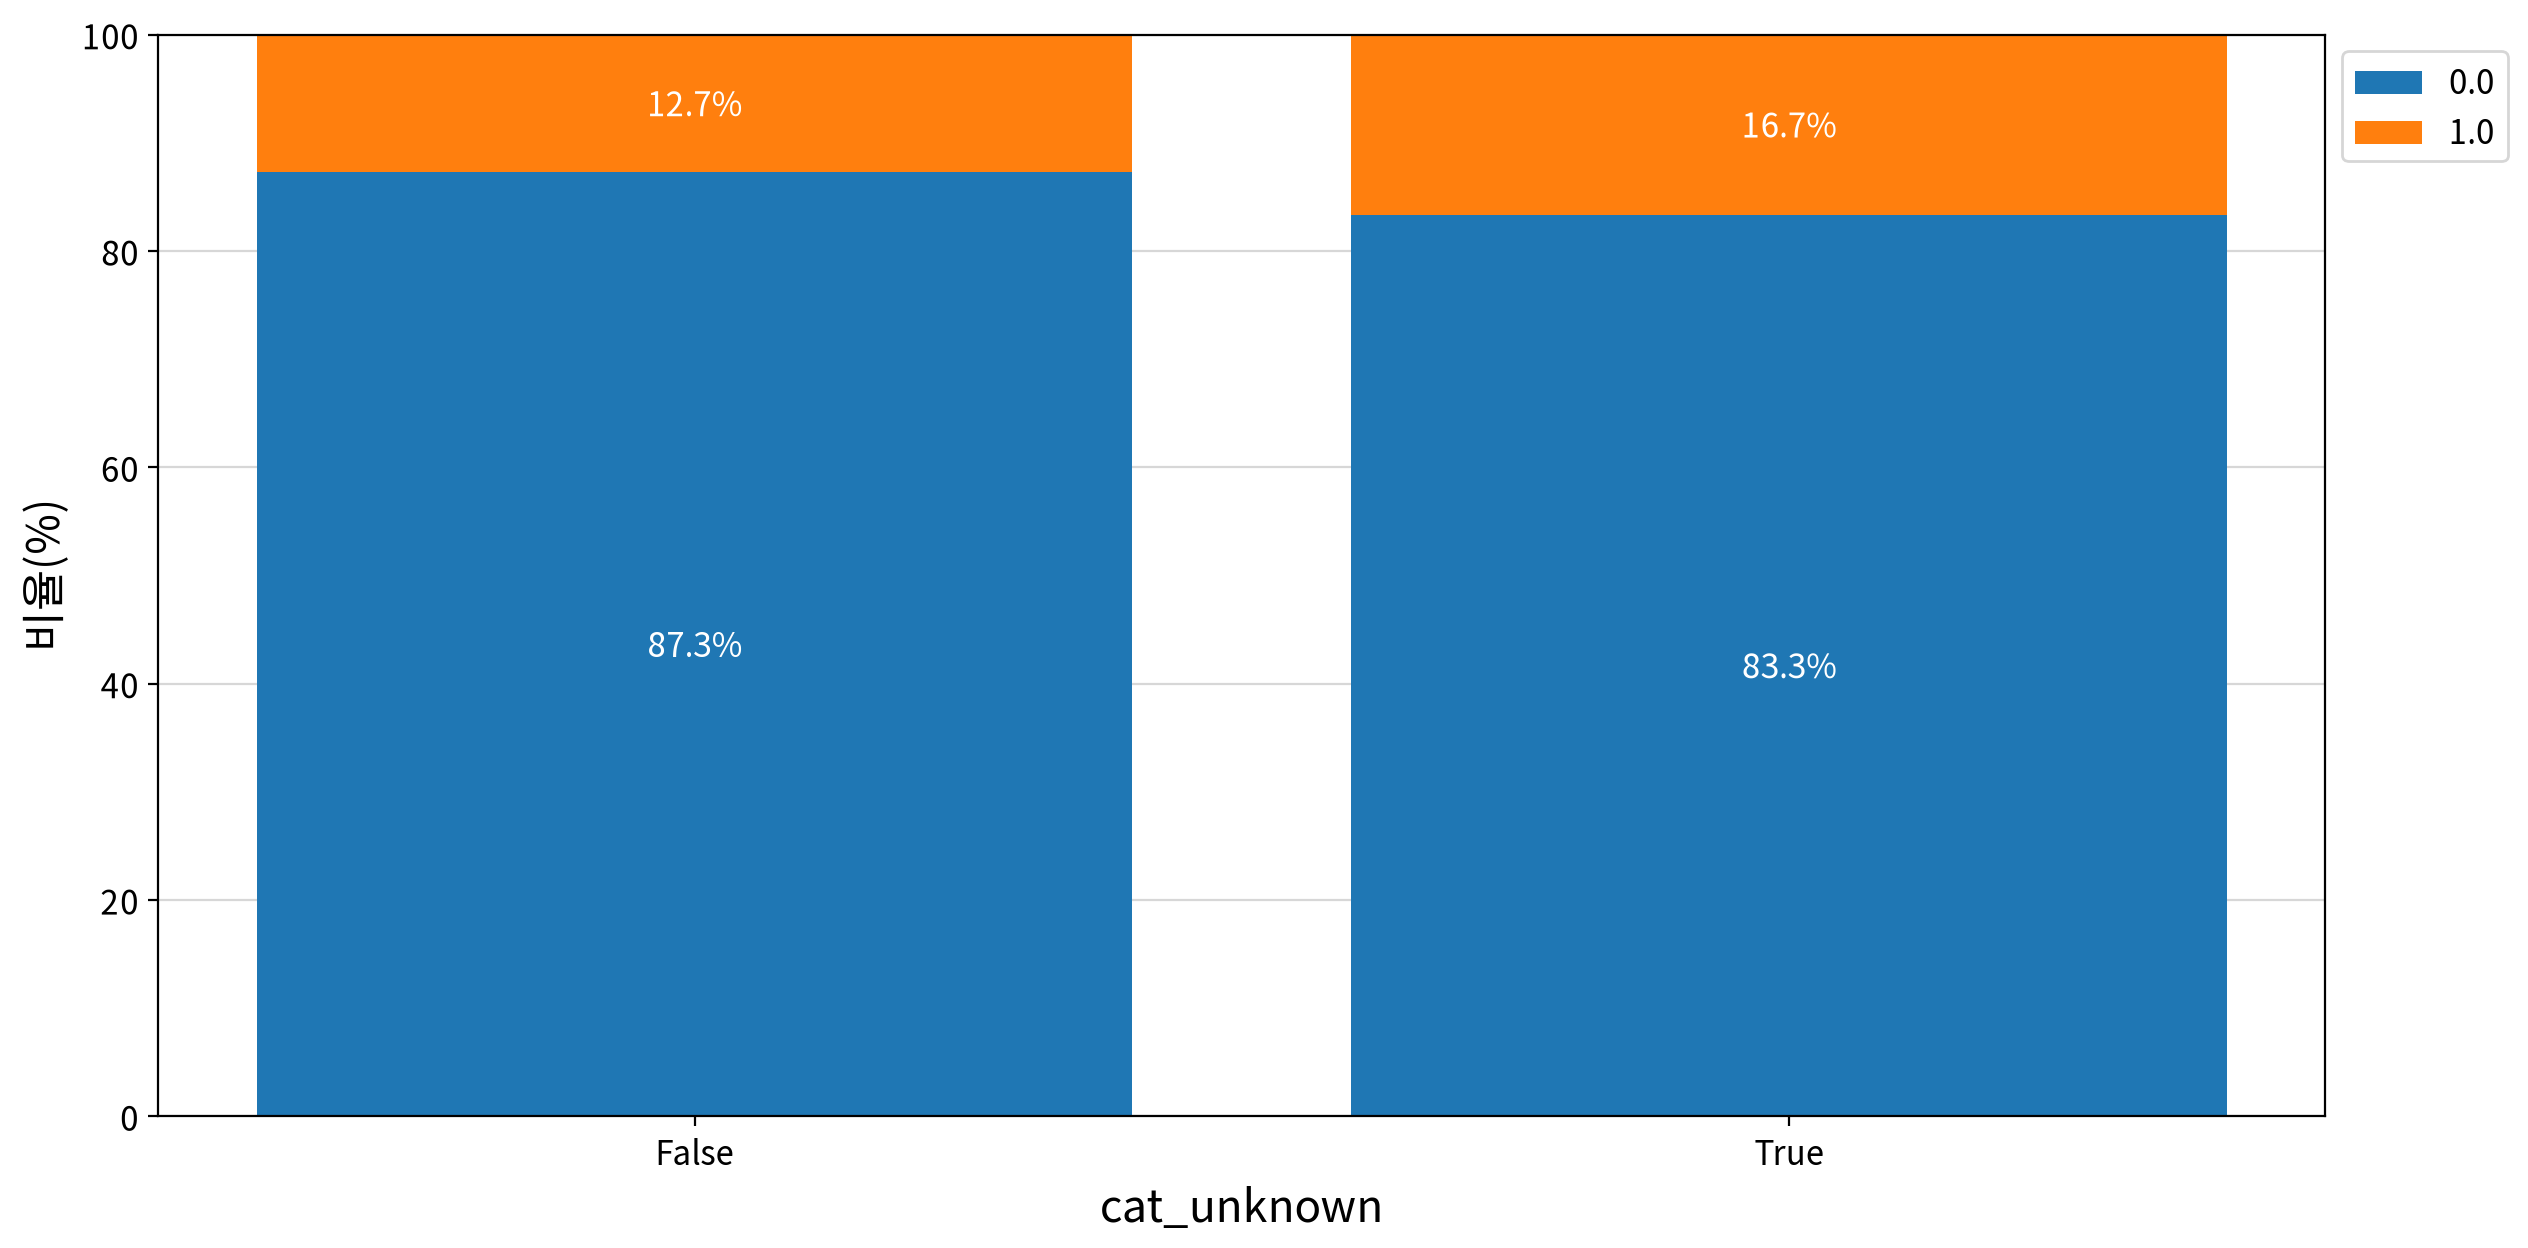

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
cat_unknown,low,Chi-square test of independence,18.3863,1,0.000018,True,0.0139,Negligible,174.92,True


In [8]:
m = master.assign(cat_unknown=master.category_en == "미상")
my_stats.chi2_independence(m, x="cat_unknown", y="late")
my_stats.chi2_independence(m, x="cat_unknown", y="low")

In [9]:
master["delivery_error_days"] = (master.order_delivered_customer_date - master.order_estimated_delivery_date).dt.days
master["expected_lead_days"]  = (master.order_estimated_delivery_date - master.purchase_ts).dt.days

my_stats.multi_correlation(master, 
    columns=["delivery_error_days","expected_lead_days","distance_km","price_sum","freight_sum","installments_max"],
    plot=False)   # 15쌍 검정 + pairplot은 무거우니 숫자표만 먼저

,delivery_error_days,expected_lead_days,distance_km,price_sum,freight_sum,installments_max
delivery_error_days,1.000,-0.564,-0.183,-0.043,-0.156,-0.053
expected_lead_days,-0.564,1.000,0.622,0.120,0.460,0.094
distance_km,-0.183,0.622,1.000,0.114,0.588,0.099
price_sum,-0.043,0.120,0.114,1.000,0.469,0.375
freight_sum,-0.156,0.460,0.588,0.469,1.000,0.231
installments_max,-0.053,0.094,0.099,0.375,0.231,1.000


method    coef  p-value  strength  \
x                   y                                                         
delivery_error_days expected_lead_days  Spearman -0.5635      0.0  Moderate   
                    distance_km         Spearman -0.1827      0.0      Weak   
                    price_sum           Spearman -0.0434      0.0      Weak   
                    freight_sum         Spearman -0.1557      0.0      Weak   
                    installments_max    Spearman -0.0535      0.0      Weak   
expected_lead_days  distance_km         Spearman  0.6220      0.0  Moderate   
                    price_sum           Spearman  0.1205      0.0      Weak   
                    freight_sum         Spearman  0.4598      0.0  Moderate   
                    installments_max    Spearman  0.0944      0.0      Weak   
distance_km         price_sum           Spearman  0.1135      0.0      Weak   
                    freight_sum         Spearman  0.5884      0.0  Moderate   
                    installments_max    Spearman  0.0987      0.0      Weak   
price_sum           freight_sum         Spearman  0.4695      0.0  Moderate   
                    installments_max    Spearman  0.3747      0.0  Moderate   
freight_sum         installments_max    Spearman  0.2311      0.0      Weak   

                                        significant  normality_x  normality_y  \
x                   y                                                           
delivery_error_days expected_lead_days         True        False        False   
                    distance_km                True        False        False   
                    price_sum                  True        False        False   
                    freight_sum                True        False        False   
                    installments_max           True        False        False   
expected_lead_days  distance_km                True        False        False   
                    price_sum                  True        False        False   
                    freight_sum                True        False        False   
                    installments_max           True        False        False   
distance_km         price_sum                  True        False        False   
                    freight_sum                True        False        False   
                    installments_max           True        False        False   
price_sum           freight_sum                True        False        False   
                    installments_max           True        False        False   
freight_sum         installments_max           True        False        False   

                                        linearity  influential_outlier  \
x                   y                                                    
delivery_error_days expected_lead_days      False                False   
                    distance_km             False                False   
                    price_sum               False                False   
                    freight_sum             False                False   
                    installments_max        False                False   
expected_lead_days  distance_km             False                False   
                    price_sum               False                False   
                    freight_sum             False                 True   
                    installments_max        False                False   
distance_km         price_sum               False                False   
                    freight_sum             False                 True   
                    installments_max        False                False   
price_sum           freight_sum             False                 True   
                    installments_max        False                False   
freight_sum         installments_max        False                False   

                                        high_skew  
x        

In [10]:
seller_orders = item_base.groupby("seller_id")["order_id"].nunique()
my_qtcheck.numerical_summary(seller_orders.to_frame("n_orders"))   # skew·log_need 확인

,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,...,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
n_orders,2945.0,33.121222,105.694847,1.0,2.0,7.0,22.0,1819.0,3.731603,large_diff,...,0.136163,0,0.0,401,0.136163,9.427545,right tail,116.790673,leptokurtic,log


In [11]:
order_max_price = item_base.groupby("order_id")["price"].transform("max")
is_max = item_base["price"] == order_max_price

tie_count = item_base[is_max].groupby("order_id").size()
tie_orders = tie_count[tie_count > 1].index
print(f"가격 동점 주문 수: {len(tie_orders)}건")

tie_items = item_base[item_base["order_id"].isin(tie_orders) & is_max]
items_per_order = item_base.groupby("order_id").size()

hyp_a = items_per_order.loc[tie_orders].eq(1).sum()
hyp_b = tie_items.groupby("order_id")["price"].apply(lambda s: (s == 0).all()).sum()
hyp_c = tie_items.groupby("order_id")["product_id"].nunique().eq(1).sum()

print(f"(a) 아이템 1개인데 동점(버그 의심): {hyp_a}건")
print(f"(b) 가격 0원 여러 개: {hyp_b}건")
print(f"(c) 같은 product_id 여러 개(정상 예상): {hyp_c}건")
print(f"미분류: {len(tie_orders) - hyp_a - hyp_b - hyp_c}건")

가격 동점 주문 수: 7431건
(a) 아이템 1개인데 동점(버그 의심): 0건
(b) 가격 0원 여러 개: 0건
(c) 같은 product_id 여러 개(정상 예상): 6548건
미분류: 883건


In [ ]:
print("distance_km 유니크 값 개수:", item_base["distance_km"].nunique())

# 주문별 최대 거리
order_max_dist = item_base.groupby("order_id")["distance_km"].transform("max")  # NaN은 자동 skip
is_max_dist = item_base["distance_km"] == order_max_dist   # 전부 NULL인 주문은 여기서 전부 False

# 전부 NULL인 주문 (6건이어야 함)
all_null_orders = item_base.groupby("order_id")["distance_km"].apply(lambda s: s.isna().all())
all_null_orders = all_null_orders[all_null_orders].index
print("전부 NULL:", len(all_null_orders), "건")

# 거리 최대 아이템들 중 seller_id가 여러 개 → 진짜 seller_rep 동점
max_items = item_base[is_max_dist]
seller_count = max_items.groupby("order_id")["seller_id"].nunique()
seller_rep_tie_orders = seller_count[seller_count > 1].index
print("seller_rep 동점(거리최대 아이템 중 셀러 여러 개):", len(seller_rep_tie_orders), "건")

print("합계(143건과 비교):", len(seller_rep_tie_orders) + len(all_null_orders))

# 동점일 때 order_item_id 오름차순이 실제로 어떻게 갈리는지 샘플 확인
sample = max_items[max_items["order_id"].isin(seller_rep_tie_orders[:5])]
sample.sort_values(["order_id", "order_item_id"])[["order_id","order_item_id","seller_id","distance_km"]]




distance_km 유니크 값 개수: 91107
전부 NULL: 477 건
seller_rep 동점(거리최대 아이템 중 셀러 여러 개): 153 건
합계(143건과 비교): 630


,order_id,order_item_id,seller_id,distance_km
1198,02e405aa2667a116637cdb4affaf93c0,1,640e21a7d01df7614a3b4923e990d40c,421.676773
1199,02e405aa2667a116637cdb4affaf93c0,2,391fc6631aebcf3004804e51b40bcf1e,421.676773
3119,0758015124a0c9af755d31a7bf0efedc,1,1900267e848ceeba8fa32d80c1a5f5a8,829.236343
3120,0758015124a0c9af755d31a7bf0efedc,2,b39d7fe263ef469605dbb32608aee0af,829.236343
4256,0a0090ae69392fa38ee742006f8c0a90,1,4a3ca9315b744ce9f8e9374361493884,316.493660
4257,0a0090ae69392fa38ee742006f8c0a90,2,d20b021d3efdf267a402c402a48ea64b,316.493660
5436,0ccc28cc32fa5c8ca6a3b2d594700714,1,cca3071e3e9bb7d12640c9fbe2301306,411.992429
5437,0ccc28cc32fa5c8ca6a3b2d594700714,2,4a3ca9315b744ce9f8e9374361493884,411.992429
6185,0ea7c4f19490b13285f00729f7f9b276,1,b8a0adc91af209270c2c725168eb00fd,289.871644
6186,0ea7c4f19490b13285f00729f7f9b276,2,d2374cbcbb3ca4ab1086534108cc3ab7,289.871644


In [14]:
# 멀티셀러 주문만 대상 — 셀러 1명이면 대표 선택에 애매함이 없음
seller_per_order = item_base.groupby("order_id")["seller_id"].nunique()
multi_seller_orders = seller_per_order[seller_per_order > 1].index
mb = item_base[item_base["order_id"].isin(multi_seller_orders)]

# (a) 멀티셀러 중 거리 전부 NULL → 6건과 비교
all_null_multi = mb.groupby("order_id")["distance_km"].apply(lambda s: s.isna().all())
all_null_multi = all_null_multi[all_null_multi].index
print("멀티셀러 & 거리 전부 NULL:", len(all_null_multi), "건")

# (b) 멀티셀러 중 거리 최대 아이템의 셀러가 여러 명(진짜 동점)
order_max_dist = mb.groupby("order_id")["distance_km"].transform("max")
is_max_dist = mb["distance_km"] == order_max_dist
max_items = mb[is_max_dist]
seller_count = max_items.groupby("order_id")["seller_id"].nunique()
tie_orders = seller_count[seller_count > 1].index
print("멀티셀러 & 거리 동점:", len(tie_orders), "건")

print("합계(143건과 비교):", len(tie_orders) + len(all_null_multi))

멀티셀러 & 거리 전부 NULL: 6 건
멀티셀러 & 거리 동점: 153 건
합계(143건과 비교): 159


누적 80% 커버에 필요한 카테고리 수: 16개
누적 90% 커버에 필요한 카테고리 수: 23개
누적 95% 커버에 필요한 카테고리 수: 33개


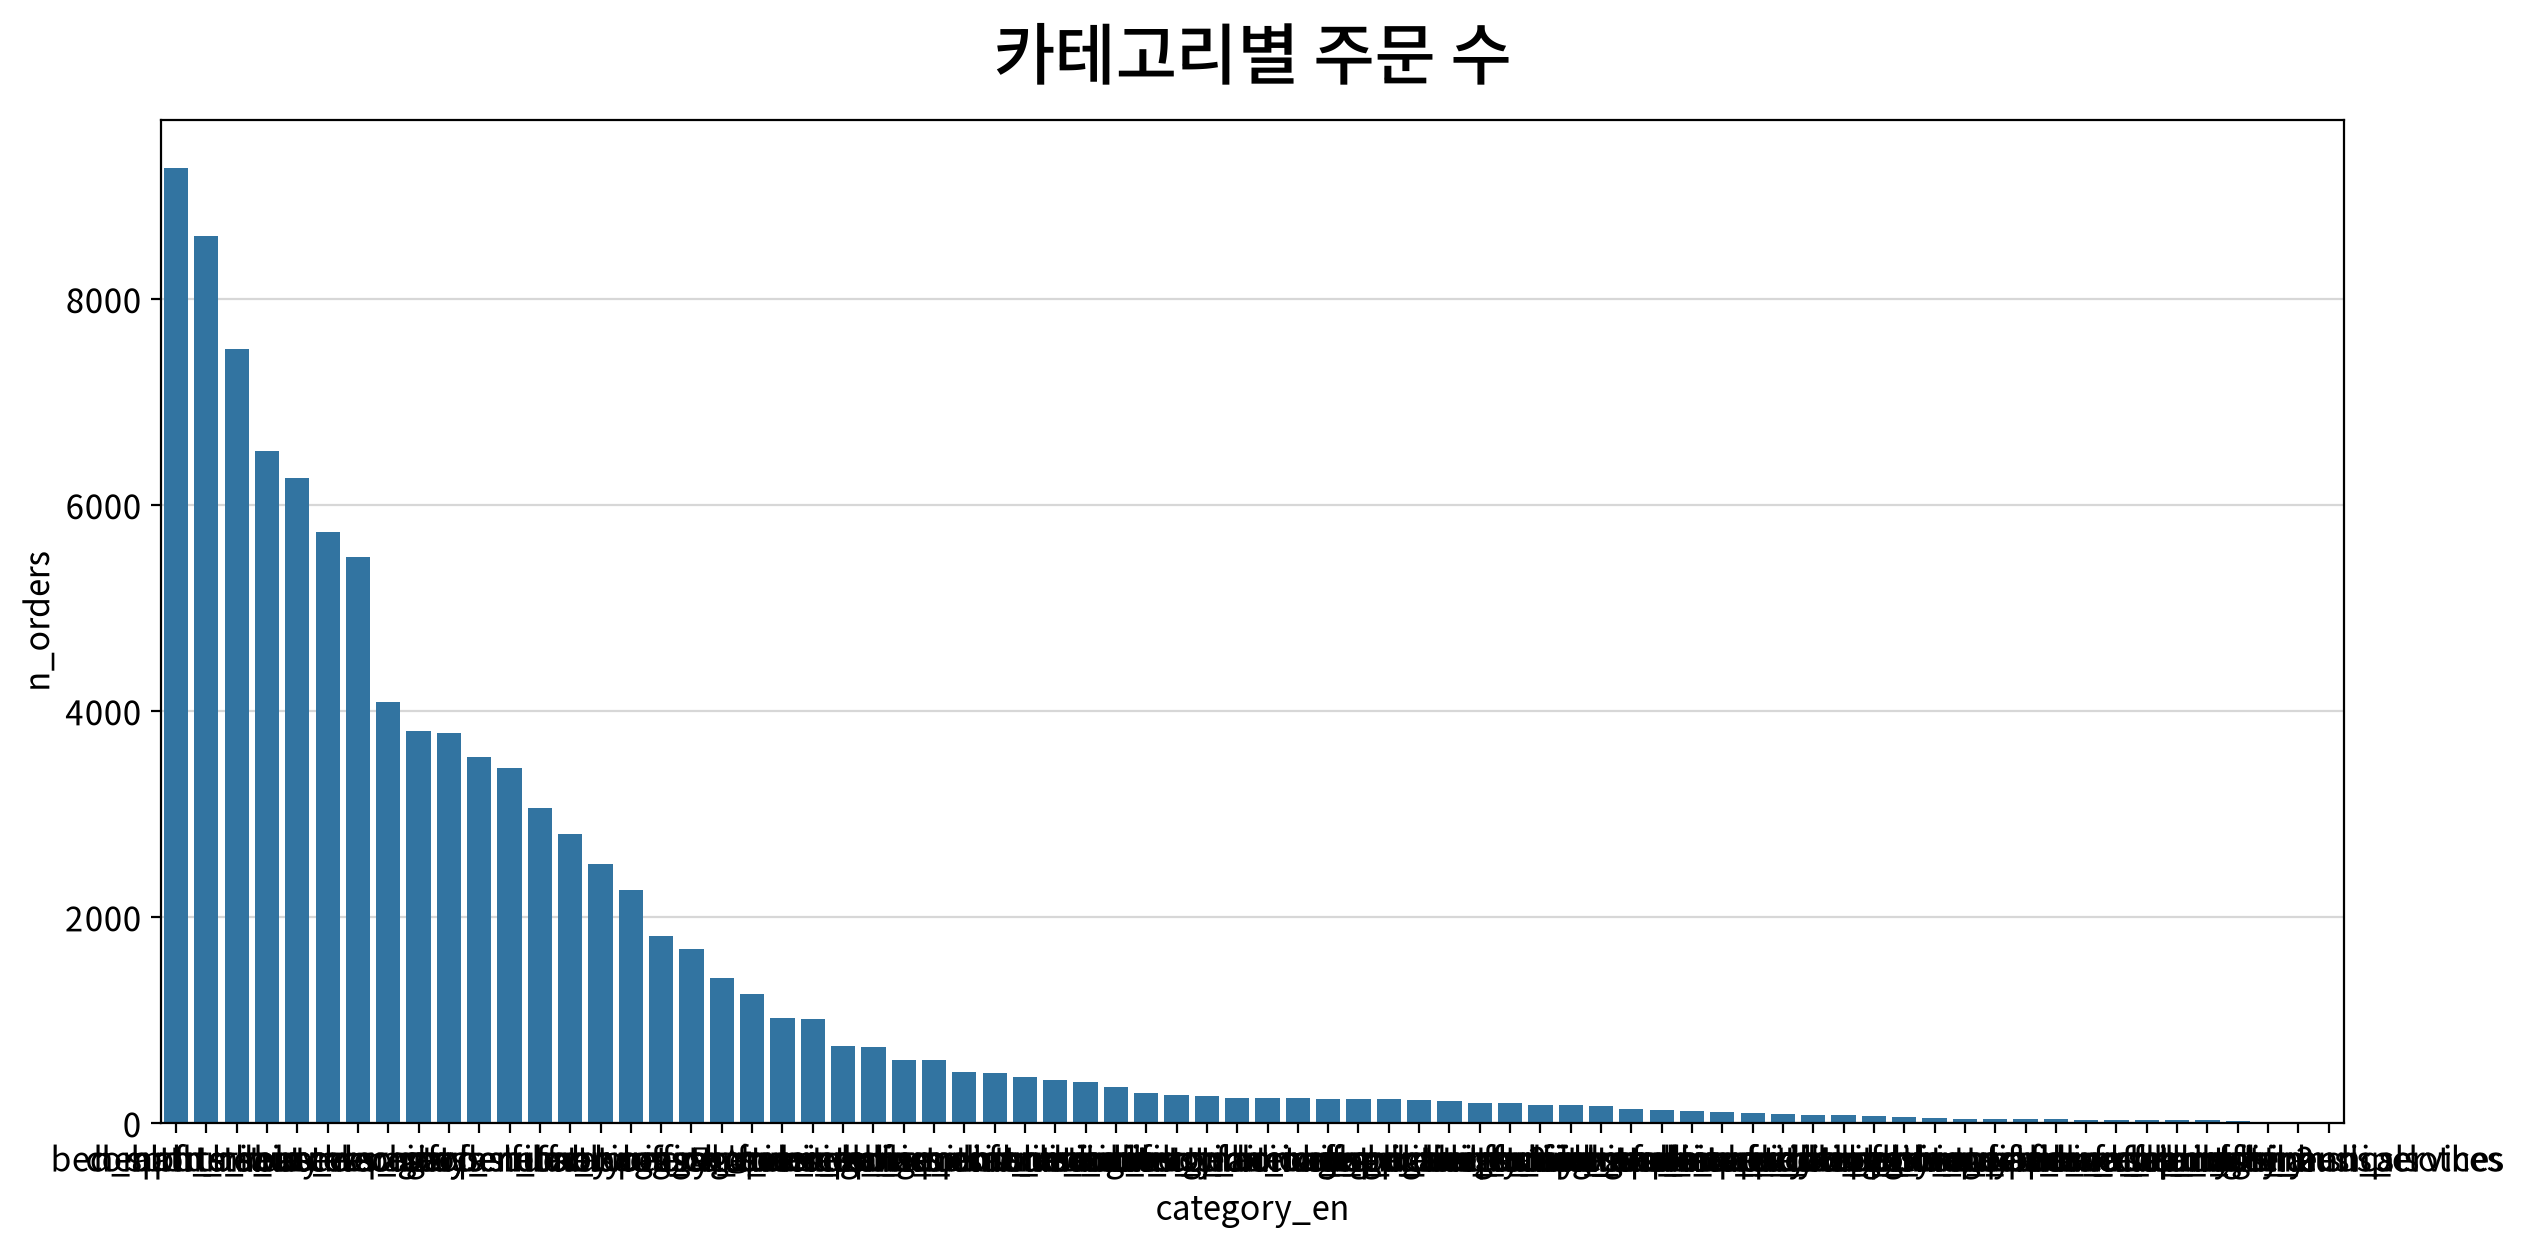

In [13]:
cat_n = (item_base.groupby("category_en")["order_id"].nunique()
                   .sort_values(ascending=False))
cat_share = (cat_n / cat_n.sum()).cumsum()

for p in [0.8, 0.9, 0.95]:
    n_needed = (cat_share <= p).sum() + 1
    print(f"누적 {int(p*100)}% 커버에 필요한 카테고리 수: {n_needed}개")

my_plot.barplot(data=cat_n.reset_index(name="n_orders"),
                 x="category_en", y="n_orders", title="카테고리별 주문 수")